In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
sns.set_theme(font='monospace', palette='Spectral')

# Pandas + Time-Series
---

<big>
    
- There isn’t a special container just for time series in Pandas, they’re just Series or DataFrames with a `DatetimeIndex`
- Each element of this index is of the type `numpy.datetime` or `pd.Timestamp` or `pd.Period`

<br>

2020-01-01     0.905398
2020-01-02     2.334489
2020-01-03     1.078428
2020-01-04    -0.681021
2020-01-05    -0.587764
                ...    
2024-12-27    21.245163
2024-12-28    21.742709
2024-12-29    22.063102
2024-12-30    21.587299
2024-12-31    22.149895
Freq: D, Length: 1827, dtype: float64

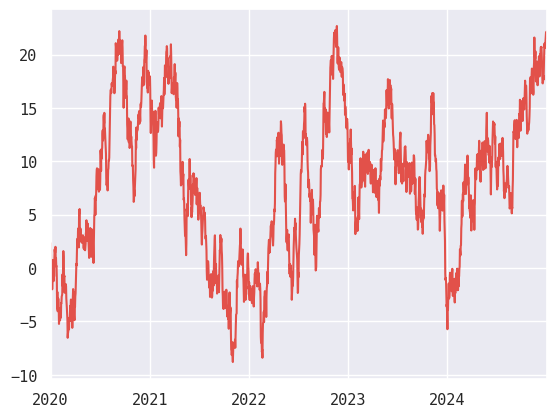

In [10]:
# creating a datetime index
idx = pd.date_range(start='2020-01-01', end='2024-12-31', freq='D')

# passing it to a series with random data to create a Time Series
srs = pd.Series(data=np.random.randn(len(idx)).cumsum(), index=idx)
srs.plot()

display(srs)

# Timestamp Attributes and Methods
---

<big> 

- These help us extract useful information from the timestamps
- A few are illustrated below

**Exercise**

- Try at least 5 attributes / methods
- See the full list [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#time-date-components)

<br>

In [15]:
timestamp.quarter

2

In [14]:
timestamp = idx[100]

pd.Series({
    'timestamp': timestamp,
    'date': timestamp.date(),
    'day': timestamp.day,
    'month': timestamp.month,
    'year': timestamp.year,
    'day name': timestamp.day_name(),
    'month name': timestamp.month_name(),
    'day of year': timestamp.day_of_year,
    'day of week': timestamp.day_of_week,
})

timestamp      2020-04-10 00:00:00
date                    2020-04-10
day                             10
month                            4
year                          2020
day name                    Friday
month name                   April
day of year                    101
day of week                      4
dtype: object

<br>

# Importing Time Series Data
---

- Using yahoo finance
- Goldman Sachs data

<br>

In [16]:
gs = \
(yf
 .download('GS','2022-01-01','2024-12-31', interval='1D', auto_adjust=True)
 .pipe(lambda fr: pd.DataFrame(
     data=fr.values, 
     index=fr.index,
     columns=[x[0] for x in fr.columns]))
)



[*********************100%***********************]  1 of 1 completed


In [17]:
gs.head()

,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,358.986664,362.591696,351.731206,353.238603,3334300.0
2022-01-04,370.019745,372.562325,364.298897,365.252385,3916400.0
2022-01-05,361.983337,374.723537,361.311376,372.126447,3469600.0
2022-01-06,360.439606,364.317076,350.904887,364.135451,2960900.0
2022-01-07,360.966278,363.726786,358.260224,361.111572,2360700.0


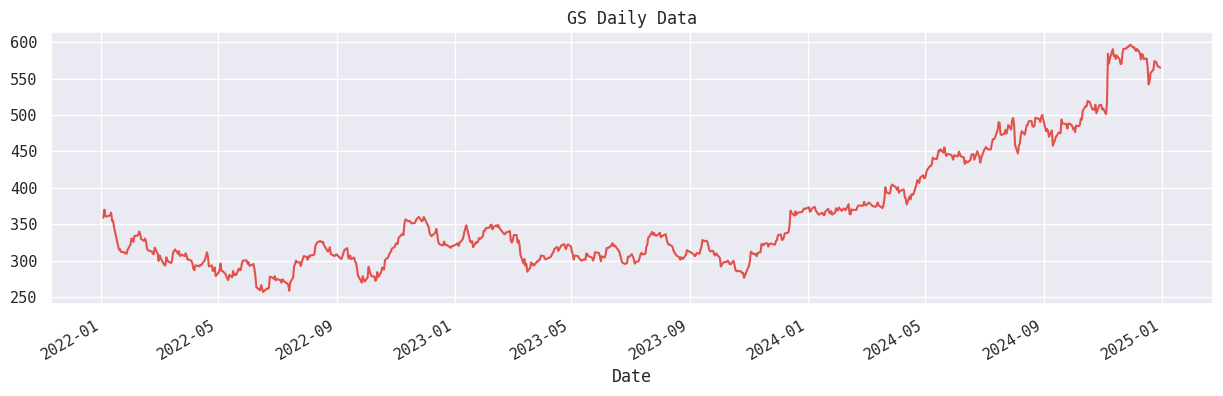

In [18]:
gs['Close'].plot(figsize=(15, 4), title='GS Daily Data');

<br>

## Time Series Index attributes
---

<br>

In [19]:
gs.index.min()

Timestamp('2022-01-03 00:00:00')

In [20]:
gs.index.max()

Timestamp('2024-12-30 00:00:00')

In [35]:
(gs[['Close']]
    .groupby(gs.index.month_name())
    .agg(('first', 'last'))
)

Close            
                first        last
Date                             
April      301.629852  413.217224
August     305.186462  500.046753
December   357.720917  564.865540
February   330.591370  376.748016
January    358.986664  369.250732
July       274.996887  495.917297
June       295.785004  440.668121
March      299.784760  404.482422
May        283.544220  444.759979
November   322.768829  596.400696
October    276.999023  507.435944
September  308.805481  485.209473

In [ ]:
# Try some others

<br>

## Feature 1: Special Slicing
---
<big>
    
- Using `.loc` and providing strings as dates, we can filter data for any range flexibly
- Provide any granularity in the format `'YYYY-MM-DD':'YYYY-MM-DD'`
- Label slicing is inclusive, '2025' will return any rows where 2025 is in the date

<br>

In [64]:
gs.loc['2024-01':'2024-11-01']

,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,373.375793,374.183534,367.500644,368.279509,2263100.0
2024-01-03,367.116058,370.587295,362.279386,369.125726,2265300.0
2024-01-04,368.231506,372.212372,367.269941,368.808422,1618300.0
2024-01-05,371.587311,374.500853,366.433305,367.241046,2913900.0
2024-01-08,373.914246,374.125791,367.346768,371.135337,1902600.0
...,...,...,...,...,...
2024-10-28,513.110168,514.099981,504.682104,505.093748,1687100.0
2024-10-29,513.796204,516.696975,510.581764,510.758157,1281600.0
2024-10-30,513.913818,520.175995,512.610397,512.933815,1441600.0


In [37]:
gs.loc['2024']

,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,373.375793,374.183534,367.500644,368.279509,2263100.0
2024-01-03,367.116058,370.587295,362.279386,369.125726,2265300.0
2024-01-04,368.231506,372.212372,367.269941,368.808422,1618300.0
2024-01-05,371.587311,374.500853,366.433305,367.241046,2913900.0
2024-01-08,373.914246,374.125791,367.346768,371.135337,1902600.0
...,...,...,...,...,...
2024-12-23,562.137451,562.984415,553.293383,556.444941,1519500.0
2024-12-24,573.965637,573.965637,562.708712,565.505737,913400.0
2024-12-26,572.429199,573.768652,568.755697,569.395879,1092000.0


In [38]:
gs.loc['2022':'2023']

,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,358.986664,362.591696,351.731206,353.238603,3334300.0
2022-01-04,370.019745,372.562325,364.298897,365.252385,3916400.0
2022-01-05,361.983337,374.723537,361.311376,372.126447,3469600.0
2022-01-06,360.439606,364.317076,350.904887,364.135451,2960900.0
2022-01-07,360.966278,363.726786,358.260224,361.111572,2360700.0
...,...,...,...,...,...
2023-12-22,366.019806,368.750648,364.827474,367.317925,1538200.0
2023-12-26,366.942902,367.904467,365.442862,366.019807,837300.0
2023-12-27,369.702637,370.923814,365.692897,366.548704,1367200.0


In [42]:
(gs
    .loc['2022':'2023']
    .pipe(lambda fr: {'max': fr.index.max(), 'min': fr.index.min()})
)

{'max': Timestamp('2023-12-29 00:00:00'),
 'min': Timestamp('2022-01-03 00:00:00')}

In [ ]:
(gs
    .loc['2020-03-15':'2022-07-25']
    .pipe(lambda fr: {'max': fr.index.max(), 'min': fr.index.min()})
)

In [43]:
gs.loc['2022-07':'2024-06']

,Close,High,Low,Open,Volume
Date,,,,,
2022-07-01,274.996887,276.007781,268.095075,271.357567,1749400.0
2022-07-05,273.131256,273.269103,265.007139,269.271382,2480900.0
2022-07-06,269.969910,273.259972,267.065818,272.276619,1774500.0
2022-07-07,274.417908,274.849846,269.822832,273.554031,2046500.0
2022-07-08,272.460419,276.522478,271.173803,276.164049,1438900.0
...,...,...,...,...,...
2024-06-24,450.186493,451.579649,438.407937,439.625736,1882200.0
2024-06-25,445.597809,452.125198,444.984033,447.624215,1555900.0
2024-06-26,444.116974,446.133658,440.794842,443.678584,2131700.0


<br>

## Feature 2: Resampling
---
<big>

- alter the granularity of the data (from hours to days to weeks to months etc)    
- works similar to split-apply-combine using groupby
- we split the time series into time buckets, then apply a function (like mean) and combine results

The following turns our weekly data into monthly (using 'ME' for month end)

<br>

<Axes: xlabel='Date'>

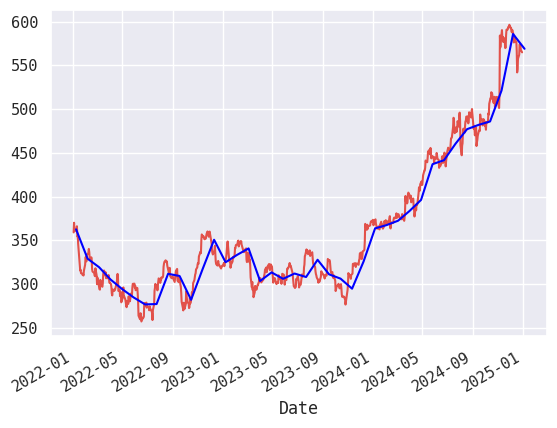

In [49]:
ax = gs['Close'].plot()
gs['Close'].resample('4W').mean().rename('Weekly').plot(ax=ax, color='blue')

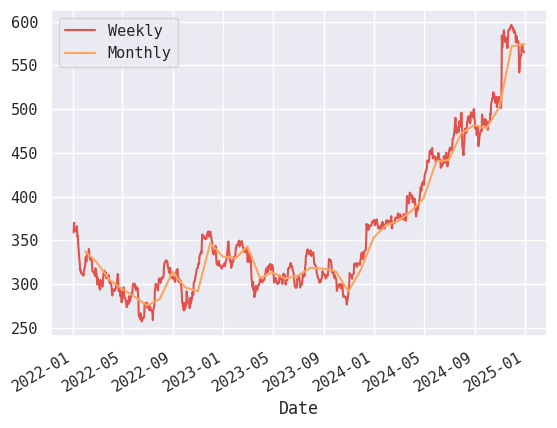

In [50]:
ax = gs['Close'].rename('Weekly').plot()

(gs['Close']
    .resample('ME')
    .mean()
    .rename('Monthly')
    .plot(ax=ax)
)

ax.legend();

<br>

## Feature 2: Window Calculations (Moving Averages)
---
<big>

using `rolling`, `expanding`, `ewm` (exponentially weighted)

- **Rolling** – a fixed‑size window that moves one step at a time, recomputing statistics on the most recent n observations (e.g., a 7‑day moving average).

- **Expanding** – starts with an initial observation and grows outward, including all data from the start up to the current point; the window size increases monotonically.

- **Sliding** – similar to a rolling window but the step can be larger than one observation, so the window “slides” forward by a specified interval (e.g., every month) while keeping a constant size.


<br>

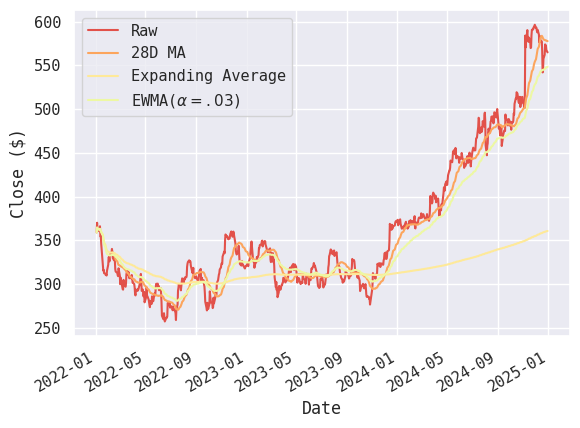

In [51]:
gs.Close.plot(label='Raw')

# Moving Average
gs.Close.rolling(28).mean().plot(label='28D MA')

# Expanding Window
gs.Close.expanding().mean().plot(label='Expanding Average')

# Exponentially Weigted Average
gs.Close.ewm(alpha=0.03).mean().plot(label='EWMA($\\alpha=.03$)')

plt.legend()
plt.ylabel("Close ($)");

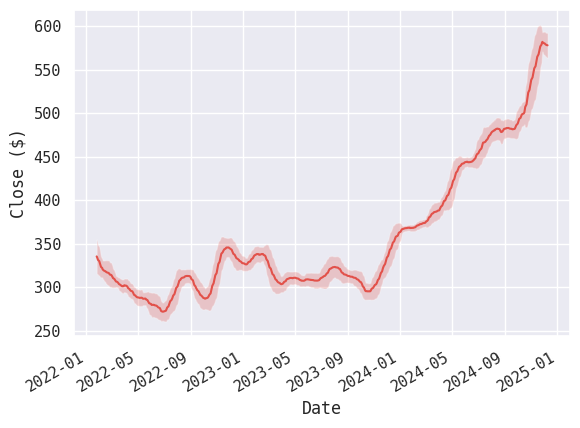

In [52]:
# 30D Moving Average

m = (gs
    .loc[:, 'Close']
    .rolling(30, center=True)
    .agg(['mean', 'std'])
    )

ax = m['mean'].plot()
ax.fill_between(m.index, 
                m['mean'] - m['std'], 
                m['mean'] + m['std'],
                alpha=.25)
plt.ylabel("Close ($)");

<br>

# Feature 4: Specialized Methods
---

- `.shift()`: takes positive or negative values to shift values in a time series back and forward in time
- `.bfill(), ffill()`: for imputing missing data forward or backwards

<br>


In [57]:
y = gs.loc['2024-01', 'Close'].round(1).head(10)

pd.DataFrame(data={
    'y': y,
    'lag_1': y.shift(1),
    'lag_2': y.shift(2),
    'lag_3': y.shift(3),
})

,y,lag_1,lag_2,lag_3
Date,,,,
2024-01-02,373.4,NaN,NaN,NaN
2024-01-03,367.1,373.4,NaN,NaN
2024-01-04,368.2,367.1,373.4,NaN
2024-01-05,371.6,368.2,367.1,373.4
2024-01-08,373.9,371.6,368.2,367.1
2024-01-09,369.0,373.9,371.6,368.2
2024-01-10,367.3,369.0,373.9,371.6
2024-01-11,365.2,367.3,369.0,373.9
2024-01-12,363.2,365.2,367.3,369.0


In [58]:
pd.DataFrame(data={
    'y': y,
    'lag_1': y.shift(1),
    'lag_2': y.shift(2),
    'lag_3': y.shift(3)
}).bfill()

,y,lag_1,lag_2,lag_3
Date,,,,
2024-01-02,373.4,373.4,373.4,373.4
2024-01-03,367.1,373.4,373.4,373.4
2024-01-04,368.2,367.1,373.4,373.4
2024-01-05,371.6,368.2,367.1,373.4
2024-01-08,373.9,371.6,368.2,367.1
2024-01-09,369.0,373.9,371.6,368.2
2024-01-10,367.3,369.0,373.9,371.6
2024-01-11,365.2,367.3,369.0,373.9
2024-01-12,363.2,365.2,367.3,369.0


<br>

## Percent Changes
---

<big>

**Percent Changes:** Percent change is $(P_t - P_{t-1}) / P_{t-1}$, representing the relative change in price. 

It is intuitive and commonly used for performance reporting.

**Relevance in Finance:**
- Percent changes are useful for understanding short-term movements and reporting.

- Used to measure risk, volatility, and to compare assets with different price levels.

**Example:**
Suppose a stock moves from 100 to 105. The percent change is 5%.

<br>

In [59]:
y.to_frame().join(y.pct_change().rename('DoD % Change').round(3))

,Close,DoD % Change
Date,,
2024-01-02,373.4,NaN
2024-01-03,367.1,-0.017
2024-01-04,368.2,0.003
2024-01-05,371.6,0.009
2024-01-08,373.9,0.006
2024-01-09,369.0,-0.013
2024-01-10,367.3,-0.005
2024-01-11,365.2,-0.006
2024-01-12,363.2,-0.005


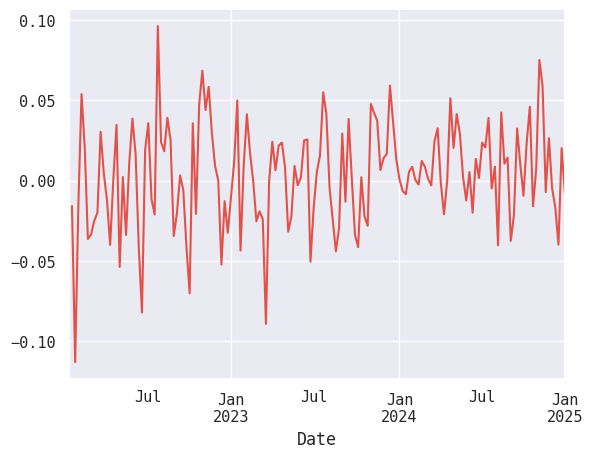

In [72]:
gs['Close'].resample('W').mean().pct_change().plot();

<big> Find the Mean and Standard Deviation for Monthly Averages

In [ ]:
(gs['Close']
    .resample('MS')
    .mean()
    .pct_change()
    .describe()
    .round(2)
)

<br>

## Differences
---

<big>

- represent change over consecutive periods


**Relevance**

- Useful in modeling


<br>

In [61]:
(y
.to_frame()
.join(y.diff().rename('DoD # Change').round(3))
 .join(y.pct_change().rename('DoD % Change').round(3))
)

,Close,DoD # Change,DoD % Change
Date,,,
2024-01-02,373.4,NaN,NaN
2024-01-03,367.1,-6.3,-0.017
2024-01-04,368.2,1.1,0.003
2024-01-05,371.6,3.4,0.009
2024-01-08,373.9,2.3,0.006
2024-01-09,369.0,-4.9,-0.013
2024-01-10,367.3,-1.7,-0.005
2024-01-11,365.2,-2.1,-0.006
2024-01-12,363.2,-2.0,-0.005
